Partie: Analyse temporelle


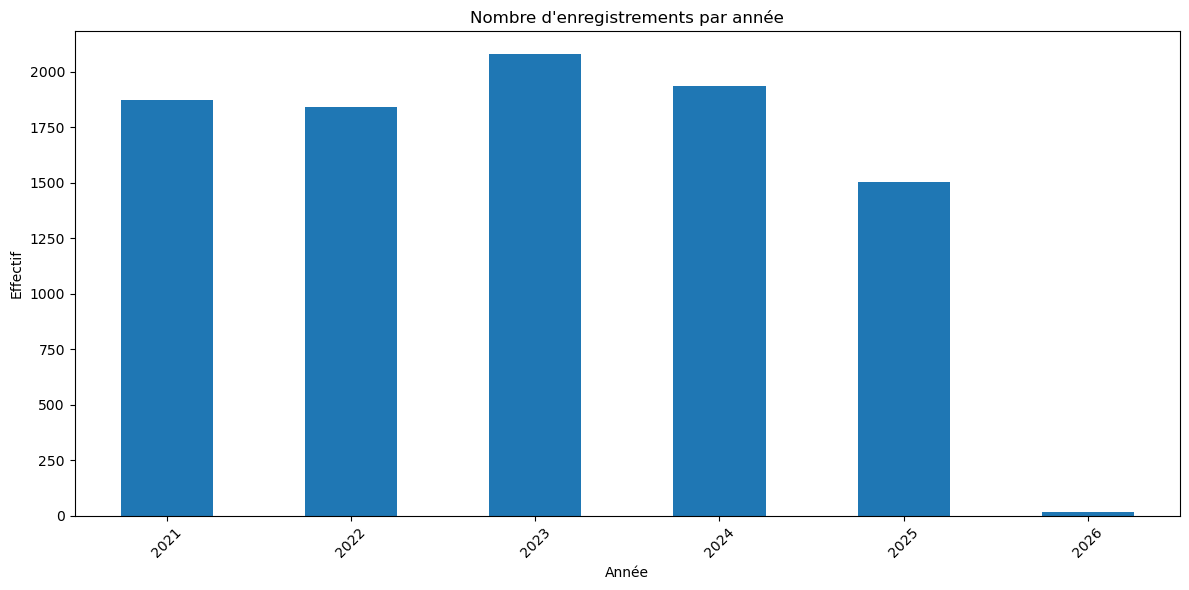

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt


with open("../data/data.json", "r", encoding="utf-8") as f:
    data = json.load(f)


df = pd.DataFrame(data)


df["annee"] = pd.to_numeric(df["annee"], errors="coerce")

# Supprimer les années manquantes
df = df.dropna(subset=["annee"])

# Compter le nombre d'enregistrements par année
counts = df["annee"].value_counts().sort_index()

# graphique

plt.figure(figsize=(12, 6))
counts.plot(kind="bar")
plt.title("Nombre d'enregistrements par année")
plt.xlabel("Année")
plt.ylabel("Effectif")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:

import plotly.express as px





df = pd.DataFrame(data)


df["annee"] = pd.to_numeric(df["annee"], errors="coerce")
df["cnu_norm"] = df["cnu_norm"].astype(str)

df = df.dropna(subset=["annee", "cnu"])
df["annee"] = df["annee"].astype(int)

# Compter le nombre d'enregistrements par année et par cnu
counts = (
    df.groupby(["cnu_norm", "annee"])
      .size()
      .reset_index(name="nb_enregistrements")
      .sort_values(["cnu_norm", "annee"])
)


fig = px.line(
    counts,
    x="annee",
    y="nb_enregistrements",
    facet_col="cnu_norm",
    facet_col_wrap=3,   
    markers=True,
    title="Nombre d'enregistrements par année et par domaine de recherche ",
    labels={
        "annee": "Année",
        "nb_enregistrements": "Nombre d'enregistrements",
        "cnu_norm": "Discipline"
    },
    hover_data={
        "annee": True,
        "cnu_norm": True,
        "nb_enregistrements": True
    }
)

# Remplacer cnu par sa valeur
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))


# Mise en forme
fig.update_layout(
    height=900,
    showlegend=False,
    title_x=0.5
)

fig.update_xaxes(dtick=1)
fig.show()

In [ ]:
#graphique général de l'évolution des enregistrements des thèses par cnu


df["annee"] = pd.to_numeric(df["annee"], errors="coerce")
df["cnu_norm"] = df["cnu_norm"].astype(str)

df = df.dropna(subset=["annee", "cnu_norm"])
df["annee"] = df["annee"].astype(int)

# Compter le nombre d'enregistrements par année et par cnu
counts = (
    df.groupby(["cnu_norm", "annee"])
      .size()
      .reset_index(name="nb_enregistrements")
      .sort_values(["cnu_norm", "annee"])
)

# graphique
fig = px.line(
    counts,
    x="annee",
    y="nb_enregistrements",
    color="cnu_norm",
    markers=True,
    title="Nombre d'enregistrements par année et par domaine de recherche",
    labels={
        "annee": "Année",
        "nb_enregistrements": "Nombre d'enregistrements",
        "cnu_norm": "Discipline"
    },
    hover_data={
        "annee": True,
        "cnu_norm": True,
        "nb_enregistrements": True
    }
)

fig.update_layout(
    height=700,
    title_x=0.5,
    legend_title_text="Discipline"
)

fig.update_xaxes(dtick=1)
fig.show()